# Exploratory Data Analysis: Fraud Detection

This notebook provides a detailed analysis of the fraud detection dataset, including statistical summaries, distribution plots, and correlation analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plot style
sns.set(style="whitegrid")

## 1. Data Loading and Initial Inspection

In [2]:
# Load datasets
train_df = pd.read_csv('Data/fraudTrain.csv', index_col=0)
test_df = pd.read_csv('Data/fraudTest.csv', index_col=0)

print(f"Train set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

Train set shape: (1296675, 22)
Test set shape: (555719, 22)


In [3]:
# Initial inspection
train_df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


## 2. Target Variable Distribution (`is_fraud`)

Checking for class imbalance.

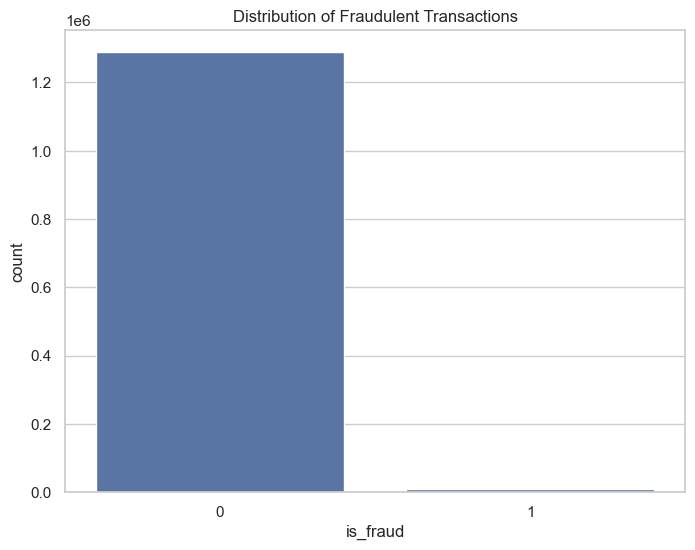

Fraud Rate: 0.58%


In [4]:
plt.figure(figsize=(8, 6))
sns.countplot(x='is_fraud', data=train_df)
plt.title('Distribution of Fraudulent Transactions')
plt.show()

fraud_rate = train_df['is_fraud'].mean() * 100
print(f"Fraud Rate: {fraud_rate:.2f}%")

## 3. Transaction Amount Analysis

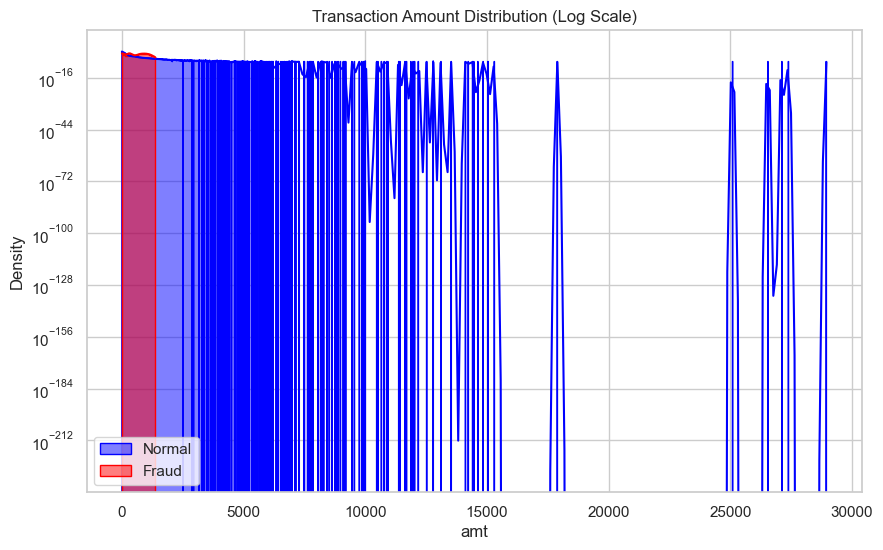

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(train_df[train_df['is_fraud'] == 0]['amt'], label='Normal', kde=True, color='blue', element='step', stat='density')
sns.histplot(train_df[train_df['is_fraud'] == 1]['amt'], label='Fraud', kde=True, color='red', element='step', stat='density')
plt.title('Transaction Amount Distribution (Log Scale)')
plt.yscale('log')
plt.legend()
plt.show()

## 4. Fraud Rate by Category

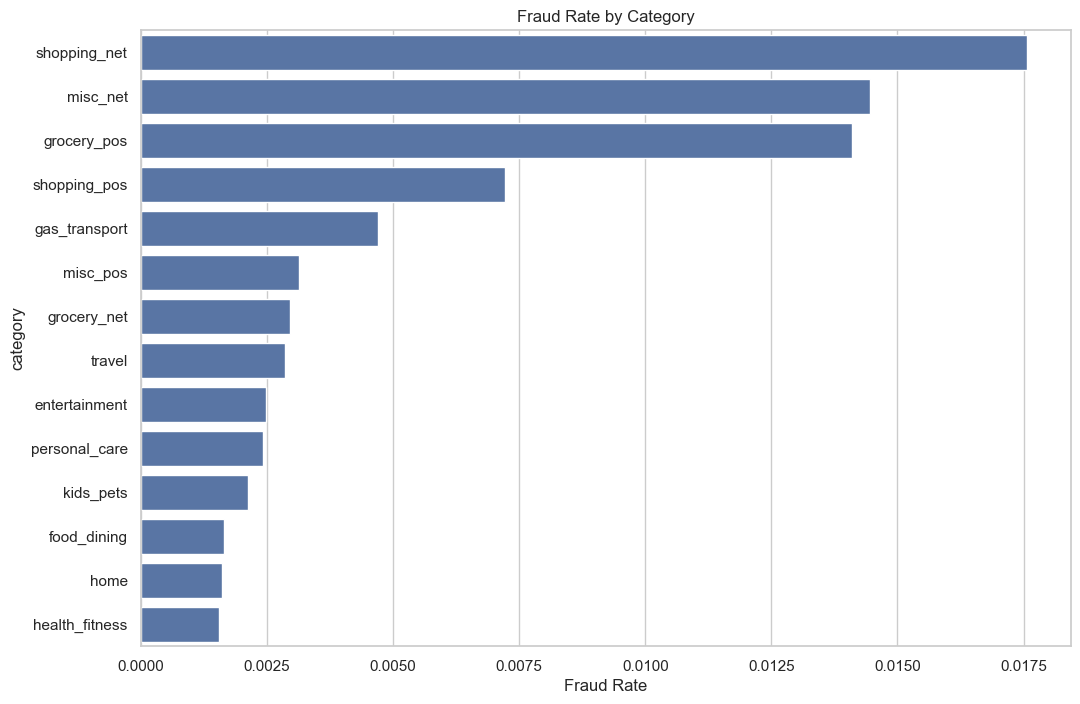

In [6]:
plt.figure(figsize=(12, 8))
fraud_by_cat = train_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False)
sns.barplot(x=fraud_by_cat.values, y=fraud_by_cat.index)
plt.title('Fraud Rate by Category')
plt.xlabel('Fraud Rate')
plt.show()

## 5. Correlation Heatmap

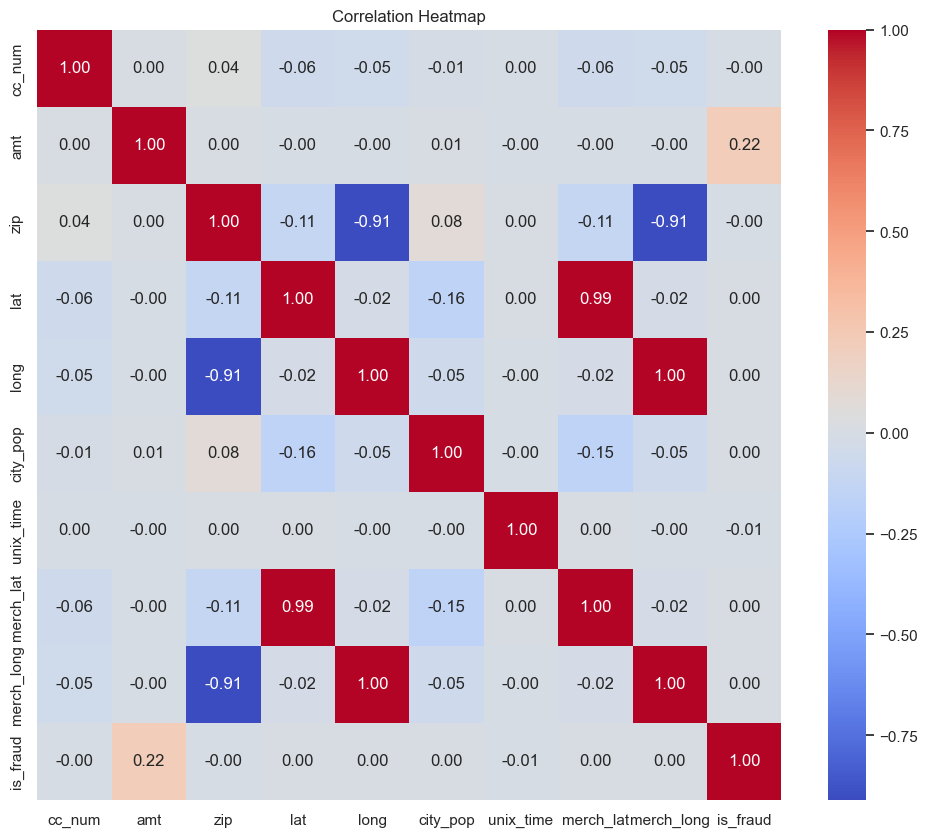

In [7]:
plt.figure(figsize=(12, 10))
numeric_cols = train_df.select_dtypes(include=[np.number]).columns
corr = train_df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()